This notebook is produce inline with the course produced by Prof. Zhengtao Gan (The University of Texas at El Paso), from which the format and conventions are adopted. For his course please follow https://drzgan.github.io/Python_CFD/0.intro_CFD.html. 

# Computational Fluid Dynamics (CFD)

CFD is a field of study that focuses on using numerical methods to analyse and solve governing equations in fluid dynamics that, at the highest level, have particularly complicated or non-existent analytical solutions. Fluid dynamics (FD) are ultimately governed by the Navier-Stokes Equations (NS Eq<sup>n</sup>):

- Momentum equation $\frac{\partial \vec{u}}{\partial t} + (\vec{u} \cdot \nabla) \vec{u}  = -\frac{1}{\rho} \nabla p + \nu \nabla ^2 \vec{u} + f$
- Continuity equation $\nabla \cdot \vec{u} = 0$

where $\vec{u}$ os the velocity field, $\rho$ is the fluid density, $p$ the pressure field, $\nu$ is the kinematic velocity, $f$ represents some body force (e.g. gravity) and all other symbols represent their usual notation.

The computational techniques developed in this notebook aim to transform PDEs into linear algebraic eq<sup>ns</sup>. Techniques include the *Finite Element Method*, *Finite Difference Method*, and *Finite Volume Method*, with which approximate models can be readily produced.

## 1<sup>D</sup> Linear Convection

The 1<sup>D</sup> Linear Convection Eq<sup>n</sup> or 1st-Order Wave Eq<sup>n</sup> is one of the simplest FD model:

$$\frac{\partial u}{\partial t} \pm c\frac{\partial u}{\partial x} = 0$$

This eq<sup>n</sup> represents the propagation of a wave with speed $c$ either 'left' or 'right' ($\pm$ respectively) that does not change shape. We fix the initial condition $u(x, 0) = u_0(x)$. By direct substitution we can show that $u(x, t) = u_0 (x \mp ct)$. Let $\eta = x \mp ct$. Using the chain rule:

$$\frac{\partial u_0}{\partial t} = \frac{d u_0}{d \eta} \frac{\partial \eta}{\partial t} \equiv \mp c \frac{d u_0}{d \eta}$$

and

$$\frac{\partial u_0}{\partial x} = \frac{d u_0}{d \eta} \frac{\partial \eta}{\partial x}  \equiv \frac{d u_0}{d \eta}$$

therefore

$$LHS = \mp c \frac{d u_0}{d \eta} \pm c \frac{d u_0}{d \eta} = 0 = RHS$$

For now let $c$ absorb the sign. To solve this equation numerically we discretise in space and time using Forward/ Backward Difference scheme for the time/ space derivative respectively. Space is unitised into points indexed from $i = 0, 1, ..., N$ and time intervals are taken in steps of $\Delta t$. Using the definition of the derivative:

$$\frac{\partial u}{\partial x} \approx \frac{u(x + \Delta x) - u(x)}{\Delta x} \lim_{\Delta x \rightarrow 0}(\approx \rightarrow =)$$
$$\implies \frac{u_i^{n+1} - u_i^n}{\Delta t} + c \frac{u_i^{n} - u_{i-1}^n}{\Delta x} = 0$$

Where $n$ and $n+1$ are consecutive time steps and $i$ and $i-1$ are neighbouring points in space. With known initial conditions it therefore follows that:


$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x}(u_i^{n} - u_{i-1}^n)$$

Let's analyse this in python, starting by initialising our libraries.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Plots appear in notebook rather than seperate view
%matplotlib inline

We define an evenly spaced grid of points, e.g. $x \in [0,1]$. Let `nx` be the number of grid point and `dx` or `dt` be a constant spacing between any pair of adjacent points.

The initial velocity $u_0$ can be configured in the function below, so long as it always produces a numpy array. For this investigation we will use a top hat function:

$$ u_0 = \begin{cases} 1 & 0.2 < x < 0.3 \\ 0 & \text{elsewhere} \end{cases}$$

In [2]:
def top_hat(nx: int, domain: list[float] = [0.0, 1.0], centre: float = 0.25, width: float = 0.1, max: float = 1.0, min: float = 0.0) -> np.ndarray:
    x = np.linspace(domain[0], domain[1], nx)
    mask = abs(x - centre) <= width / 2

    array = np.full(nx, min, dtype=float)
    array[mask] = max
    return array, x

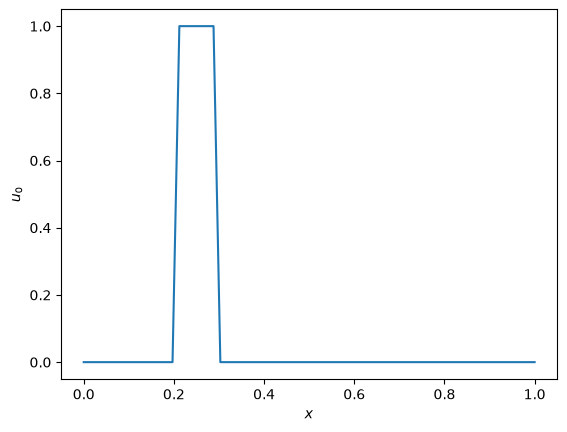

In [3]:
nx, x_range = 67, [0.0, 1.0]

u_0, x = top_hat(nx=nx, domain=x_range)
plt.plot(x, u_0)
plt.xlabel(r"$x$")
plt.ylabel(r"$u_0$")
plt.show()

We simulateneously define the number of timesteps, `ntsteps`, `dt`, and `c`. `matplotlib.pyplot` still defines the plotting environment and can be used to plot at the expense of a simple configurations. 

Let's explore how this state evolves over time under the discretised convection eq<sup>n</sup>, performing our numeric approximation outlined previously. We first initialise the evolution array (preventing excessive storage allocation) and then populate it with sucessive speed timesteps. For a given $n$ in time, the function numerically finds the next spatial state from the previous one; implemented by nesting the spatial loop in the temporal loop.

In [4]:
def linear_convection(u_0: np.ndarray, domain: list[float], nx: int, nt: int, dt: float, c: float = 1.0) -> np.ndarray:
    dx = abs(domain[1] - domain[0]) / (nx - 1) # Last point must exist at ends of grid so spacing requires 1 less free point.
    
    u = np.zeros([nt+1, nx]) # add timestep for initial condition
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()  # keep boundary values consistent
        for i in range(1, nx): # start at 1 so that i-1 doesn't produce -1 (use end of array)
            u[n+1, i] = u[n, i] - c * dt/dx * (u[n, i] - u[n, i-1])

    return u

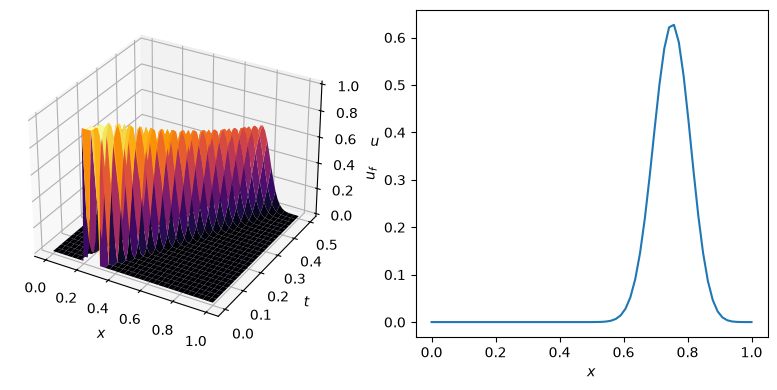

In [5]:
nx, x_range = 67, [0.0, 1.0]
nt, dt = 50, 0.01

u_0, x = top_hat(nx=nx, domain=x_range)
u = linear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt, dt=dt)
t = np.linspace(0, nt * dt, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, T, u, cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(122)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

As we can see the hat is successfully progressing over time at a constant speed. The final state on the right has moved, but the hat has smoothed over time. Furthermore, while testing it was reveled that unstable artefacts may appear for runs with reversed speed or lower temporal resolution.

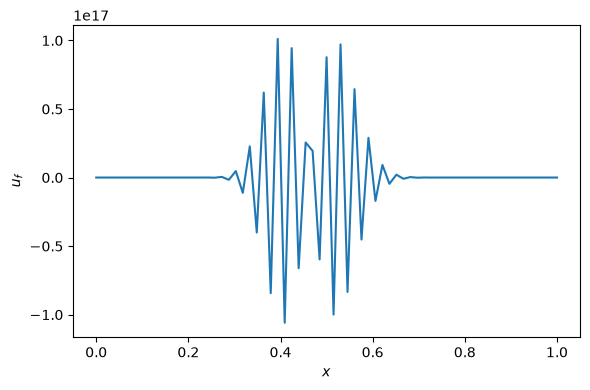

In [6]:
nx, x_range = 67, [0.0, 1.0]
nt, dt = 50, 0.01

u_0, x = top_hat(nx=nx, domain=x_range)
u = linear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt, dt=dt, c=-1.0)

X, T = np.meshgrid(np.linspace(x_range[0], x_range[1], nx), np.linspace(0, nt*dt, nt))

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(x, u[-1])
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

A big part of this error will be the accuracy of our finite difference schemes. Our two differencing schemes have error $\mathcal{O}(\Delta x)$ which when combined produce a central differencing scheme with error $\mathcal{O}(\Delta x^2)$

## Nonlinear Convection

Suppose instead we had a feedback loop for the speed of the wave, i.e. it's speed was coupled to its motion somehow. Dimensionally we can assert that the 1<sup>D</sup> Linear Convection Eq<sup>n</sup> is

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0$$

absorbing the sign for now. This is now a nonlinear eq<sup>n</sup>. Using the same discretisation we now have a nonlinear numerical solution:

$$u_i^{n+1} = u_i^n - u_i^n \frac{\Delta t}{\Delta x}(u_i^{n} - u_{i-1}^n)$$

Let's see how this evolves over time with a more granular resolution.

In [7]:
def nonlinear_convection(u_0: np.ndarray, domain: list[float], nx: int, nt: int, dt: float) -> np.ndarray:
    dx = abs(domain[1] - domain[0]) / (nx - 1)

    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx):
            u[n+1, i] = u[n, i] * (1 - dt/dx * (u[n, i] - u[n, i-1]))

    return u

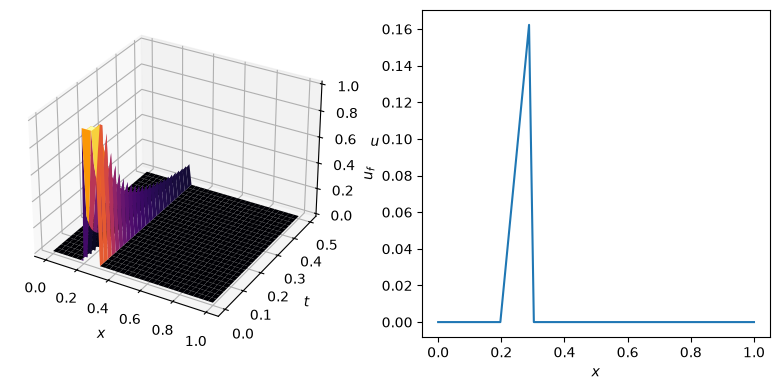

In [8]:
nx, x_range = 67, [0.0, 1.0]
nt, dt = 50, 0.01

u_0, x = top_hat(nx=nx, domain=x_range)
u = nonlinear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt, dt=dt)
t = np.linspace(0, nt * dt, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, T, u, cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(122)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

To stress-test the approximation, let's also observe if the initial conditions (speeds) where switched to negative values. While we don't know yet if the shape is correct, we are anticipate the same shape but inveretd.

C:\Users\sam.greenish\AppData\Local\Temp\ipykernel_34852\2067364746.py:10: RuntimeWarning: overflow encountered in scalar multiply
  u[n+1, i] = u[n, i] * (1 - dt/dx * (u[n, i] - u[n, i-1]))
C:\Users\sam.greenish\AppData\Local\Temp\ipykernel_34852\2067364746.py:10: RuntimeWarning: invalid value encountered in scalar subtract
  u[n+1, i] = u[n, i] * (1 - dt/dx * (u[n, i] - u[n, i-1]))
C:\Users\sam.greenish\AppData\Local\Temp\ipykernel_34852\2067364746.py:10: RuntimeWarning: invalid value encountered in scalar multiply
  u[n+1, i] = u[n, i] * (1 - dt/dx * (u[n, i] - u[n, i-1]))


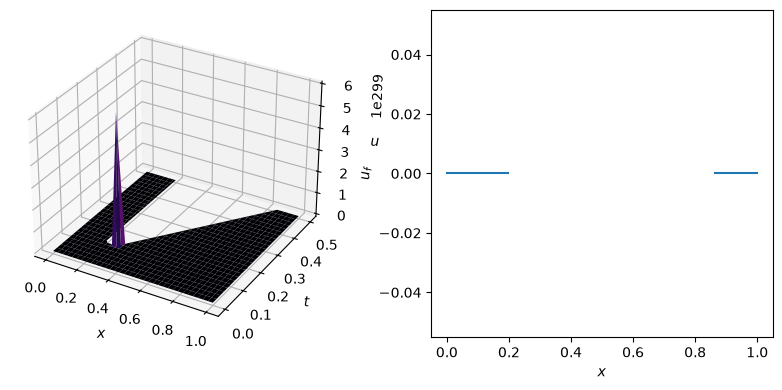

In [9]:
nx, x_range = 67, [0.0, 1.0]
nt, dt = 50, 0.01

u_0, x = top_hat(nx=nx, domain=x_range)
u = nonlinear_convection(u_0=-u_0, domain=x_range, nx=nx, nt=nt, dt=dt)
t = np.linspace(0, nt * dt, u.shape[0])
X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, T, u, cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(122)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

The method has clearly failed for negative values. This is due to limitations in the backward scheme, $\frac{u_i^n - u_{i-1}^n}{\Delta x}$, which is much less effective when dealing with nonlinear convection coefficients. To address this issue, we introduce an upwind scheme to handle both positive and negative convection coefficients.

In [10]:
def upwind_scheme(c: float):
    return max(c/(abs(c)+1e-6), 0), max(-c/(abs(c)+1e-6), 0)

def upwind_nonlinear_convection(u_0: np.ndarray = u_0, domain: list = x_range, nt: int = nt, nx: int = nx, dt: float = dt) -> np.ndarray:
    dx = abs(domain[1] - domain[0]) / (nx - 1)

    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx-1): # ignore last iteration as differential value depends on (i+1)th value
            
            # Coefficients to west & east side of the node (i-1) or (i+1) respectively
            fe1, fe2 = upwind_scheme(u[n, i])
            fw1, fw2 = upwind_scheme(u[n, i])

            # Differential values on west & east side interface
            ue = u[n, i] * fe1 + u[n, i+1] * fe2
            uw = u[n, i-1] * fw1 + u[n, i] * fw2

            u[n+1, i] = u[n, i] * (1 - dt/dx * (ue - uw))

    return u

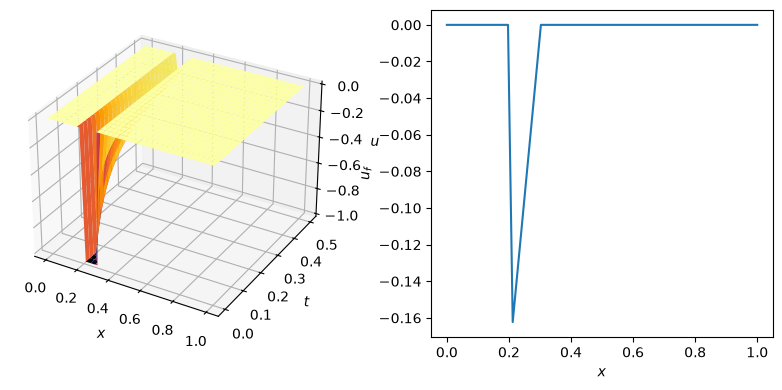

In [11]:
nx, x_range = 67, [0.0, 1.0]
nt, dt = 50, 0.01

u_0, x = top_hat(nx=nx, domain=x_range)
u = upwind_nonlinear_convection(u_0=-u_0, domain=x_range, nx=nx, nt=nt, dt=dt)
t = np.linspace(0, nt * dt, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, T, u, cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(122)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

This has now produced the same shape as the positive initial condition and stabalised the handling of negative values.

# Convergence & the CFL Condition

Going back to the linear convections, this section aims to resolve why do the numercial solutions diffuse over time, and the divergence at negative $c$. So far we've been using the fixed spatial grid and timestep parameters but how does the outcome vary with grid size and timestep?

At this point we also define the CFL, or *Courant*, number, $\sigma$, where

$$\sigma = \frac{u \Delta t}{\Delta x} \leq \sigma_{max}$$

where $u$ is the wavespeed and $\sigma_{max}$ is the maximum value for which the discretisation is stable. Let's see what this means by varying nx in a fixed range $x \in [0,1]$:

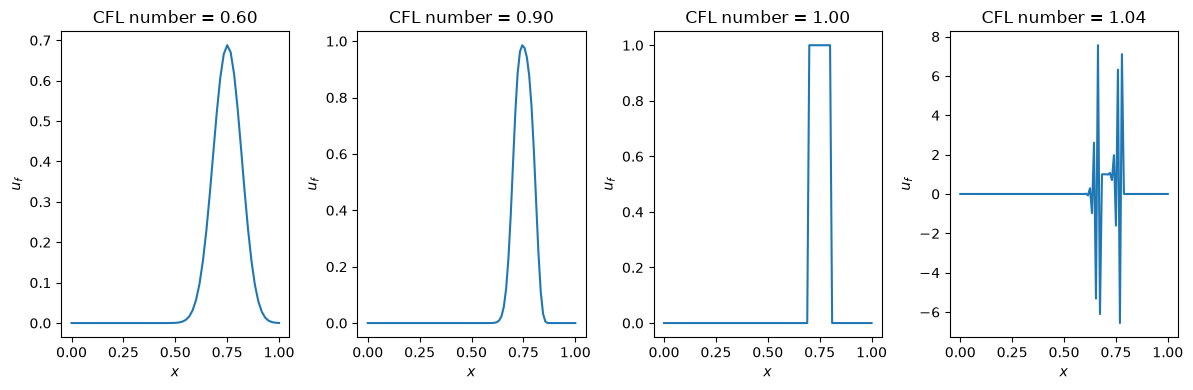

In [12]:
nxs, x_range = [61, 91, 101, 105], [0.0, 1.0]
nt, dt = 50, 0.01
c = 1.0

fig = plt.figure(figsize=(12, 4))

for nx in nxs:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    
    u_0, x = top_hat(domain=x_range, nx=nx)
    u = linear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt, dt=dt)

    ax = fig.add_subplot(1, len(nxs), nxs.index(nx)+1)
    ax.plot(x, u[-1], label=f"$nx={nx}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$u_f$")
    ax.set_title(f"CFL number = {c * dt / dx:.2f}")

plt.tight_layout()
plt.show()

As the grid resolution is increased, the accuracy of its shape increases as we numerically identify its spatial components as it propagates through discrete time. The more resolute the grid, the more the wave retains its shape. However, as the spatial resolution has been increased passed some CFL threshold the shape breaks down. This occurs because over the period $\Delta t$ the wave traverses a distance greater than the grid spacing, $\Delta x$, due to its motion as a results of its speed. Let's rebuild our linear_convection fucntion using the CFL number to calculate the optimal timestep (rearranging the CFL eq<sup>n</sup>) depending on our choice of $\Delta x$.

In [13]:
def cfl_linear_convection(u_0: np.ndarray, domain: list[float], nx: int, nt: int, c: float = 1.0, cfl: float = 0.9) -> tuple[np.ndarray, float]:
    dx = abs(domain[1] - domain[0]) / (nx - 1)
    dt = cfl * dx / abs(c)  # Adjust time step based on CFL condition
    
    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx):
            u[n+1, i] = u[n, i] - c * dt/dx * (u[n, i] - u[n, i-1])

    return u, dt

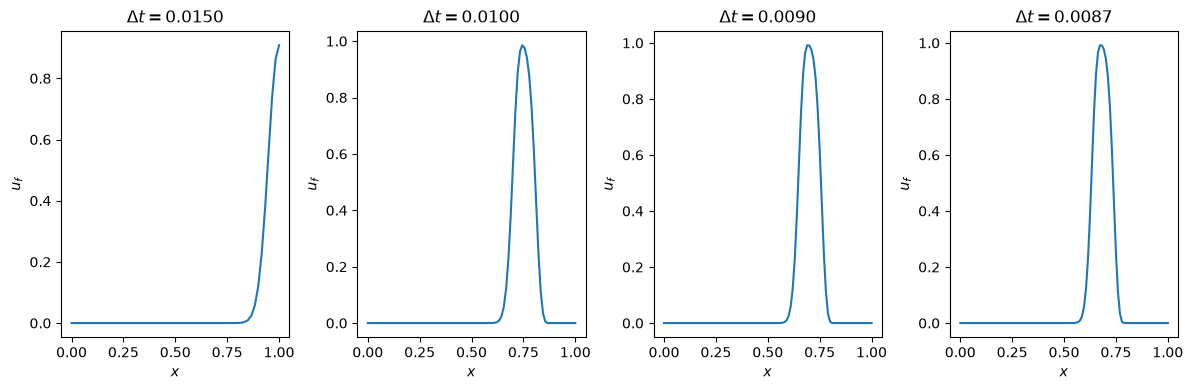

In [14]:
nxs, x_range = [61, 91, 101, 105], [0.0, 1.0]
nt = 50

fig = plt.figure(figsize=(12, 4))

for nx in nxs:
    u_0, x = top_hat(domain=x_range, nx=nx)
    u, dt = cfl_linear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt)

    ax = fig.add_subplot(1, len(nxs), nxs.index(nx)+1)
    ax.plot(x, u[-1], label=f"$nx={nx}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$u_f$")
    ax.set_title(r"$\Delta t = " + f"{dt:.4f}$")

plt.tight_layout()
plt.show()

An important observation here is that, even though the wave speed has not been changed, as the grid resolution is increased, the wave propagates a shorter distance. Clearly, as the grid resolution is increased, the timestep decreases, so for a fixed number of iterations,  it will travel under less time. The function still struggles with negative $c$ values, so the CFL number is also implemented into the upwind scheme.

In [15]:
def cfl_upwind_linear_convection(u_0: np.ndarray, domain: list[float], nx: int, nt: int, c: float = 1.0, cfl: float = 0.9) -> tuple[np.ndarray, float]:
    dx = abs(domain[1] - domain[0]) / (nx - 1)
    dt = cfl * dx / abs(c)

    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx-1):
            
            fe1, fe2 = upwind_scheme(c)
            fw1, fw2 = upwind_scheme(c)

            ue = u[n, i] * fe1 + u[n, i+1] * fe2
            uw = u[n, i-1] * fw1 + u[n, i] * fw2

            u[n+1, i] = u[n, i] - c * dt/dx * (ue - uw)

    return u, dt

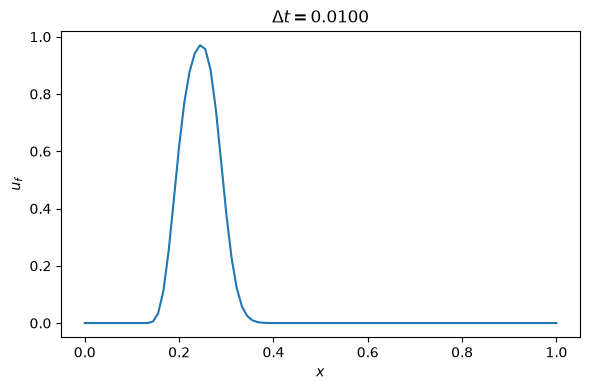

In [16]:
nx, x_range = 91, [0.0, 1.0]
nt = 50

fig = plt.figure(figsize=(6, 4))

u_0, x = top_hat(domain=x_range, nx=nx, centre=0.75)
u, dt = cfl_upwind_linear_convection(u_0=u_0, domain=x_range, nx=nx, nt=nt, c=-1.0)

ax = fig.add_subplot(111)
ax.plot(x, u[-1], label=f"$nx={nx}$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")
ax.set_title(r"$\Delta t = " + f"{dt:.4f}$")

plt.tight_layout()
plt.show()

## Diffusion eq<sup>n</sup> in 1<sup>D</sup>

The 1<sup>D</sup> diffusion eq<sup>n</sup> is

$$ \frac{\partial u}{\partial t} = \nu \frac{\partial ^2 u}{\partial x^2}$$

Discretising 2nd-order PDEs requries the Central Difference scheme: a combination of the Forward & Backward Difference of the first derivative. Consider first the Taylor expansion of $u_{i+1}$ and $u_{i-1}$ around $u_i$,

$$u_{i+1} = u_i + \Delta x \frac{\partial u}{\partial x}\Bigr|_i + \frac{\Delta x^2}{2!} \frac{\partial ^2 u}{\partial x^2}\Bigr|_i + \frac{\Delta x^3}{3!} \frac{\partial ^3 u}{\partial x^3}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

$$u_{i-1} = u_i - \Delta x \frac{\partial u}{\partial x}\Bigr|_i + \frac{\Delta x^2}{2!} \frac{\partial ^2 u}{\partial x^2}\Bigr|_i - \frac{\Delta x^3}{3!} \frac{\partial ^3 u}{\partial x^3}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

i.e.

$$u_{i+1} + u_{i-1} = 2u_i + \Delta x^2 \frac{\partial ^2 u}{\partial x^2}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

and rearranging for the second derivative,

$$\frac{\partial ^2 u}{\partial x^2} = \frac{u_{i+1} + u_{i-1} - 2u_i}{\Delta x^2} + \mathcal{O}(\Delta x^4)$$

The diffusion eq<sup>n</sup> can therefore be numerically , letting $n$ be steps in time and $i$ steps in space.

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} = \nu \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{\Delta x^2}$$

Rearranging for numerical solutions in time we get a discrete diffusion eq<sup>n</sup>

$$u^{n+1}_i = u^n_i + \frac{\nu \Delta t}{\Delta x^2} (u^n_{i+1} - 2u^n_i + u^n_{i-1})$$

In [17]:
def diffusion(u_0: np.ndarray, domain: list[float], nx: int, nt: int, sigma: float = 0.2, nu: float = 0.3) -> np.ndarray:
    dx = abs(domain[1] - domain[0]) / (nx - 1)
    dt = sigma * dx**2 / nu

    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx-1):
            u[n + 1, i] = u[n, i] + nu * dt / dx**2 * (u[n, i + 1] - 2 * u[n, i] + u[n, i - 1])

    return u, dt

Sigma, $\sigma$ is a dimensionless stability parameter that controls the magnitude of $\Delta t$ relative to the spatial grid and the diffusion coefficient $\nu$. A smaller $\sigma$ leads to a smaller $\Delta t$, which can improve stability but increase computation time.

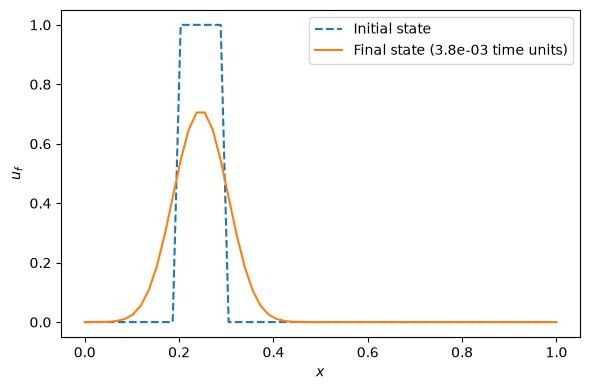

In [18]:
nx, x_range = 60, [0.0, 1.0]
nt = 20

fig = plt.figure(figsize=(6, 4))

u_0, x = top_hat(domain=x_range, nx=nx)
u, dt = diffusion(u_0=u_0, domain=x_range, nx=nx, nt=nt)

ax = fig.add_subplot(111)
ax.plot(x, u[0], "--", label="Initial state")
ax.plot(x, u[-1], label=f"Final state ({nt * dt:.1e} time units)")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")

plt.legend()
plt.tight_layout()
plt.show()

## Burgers' Eq<sup>n</sup> in 1<sup>D</sup>

Burgers' Eq<sup>n</sup> is a convection-diffusion PDE that describes many dynamical fluid/ gas/ acoustic systems:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial ^2 u}{\partial x^2}$$

It is effectively a cominbation of the nonlinear convection and diffusion equations, where we are allowing the convection to dissapate over time. We've already established numerical approximations for partial derivates so this eq<sup>n</sup> can be easily discretised:

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} + u^n_i \frac{u^{n}_i - u^n_{i-1}}{\Delta x} = \nu \frac{u^n_{i+1} - 2 u^n_i + u^n_{i-1}}{\Delta x^2}$$

As before, provided an initial condition, only the next iteration of time will be unknown, so an update in time will be:

$$u^{n+1}_i = u^n_i - u^n_i \frac{\Delta t}{\Delta x} (u^{n}_i - u^n_{i-1}) + \nu \frac{\Delta t}{\Delta x^2}(u^n_{i+1} - 2 u^n_i + u^n_{i-1})$$

### Periodic Boundary Conditions

For a slightly more interesting analysis of Burgers' Eq<sup>n</sup> let's define a new initial condition called the *Cole-Hopf transformation* that converts the nonlinear Burgers' Eq<sup>n</sup> into a linear heat equation.

$$u(x, t) = -\frac{2 \nu}{\phi} \frac{\partial \phi}{\partial x} + 4$$

$\phi \equiv \phi (x, t)$. At $t = 0$:

$$\phi(x, 0) = e^{-\frac{x^2}{4 \nu}} + e^{-\frac{(x - 2 \pi)^2}{4 \nu}}$$

This is the sum of two Gaussians centred on $x = 0, 2 \pi$ with a width controlled by $\nu$. The time-evloved analytical solution over all of $t$ is

$$\phi(x, t) = e^{-\frac{(x - 4t)^2}{4 \nu (t + 1)}} + e^{-\frac{(x - 4t - 2 \pi)^2}{4 \nu (t + 1)}}$$

with a periodic boundary condition $u(0) = u(2 \pi)$

While the initial condition isn't too difficult to evaluate manually, the `SymPy` library, like mathematica, can automate these processes but with the added benefit of remaining in the Python environment. `SymPy` is first instructed to render its outputs in $\LaTeX$ for improved readability.

In [19]:
sp.init_printing(use_latex=True)

In [20]:
x, nu, t = sp.symbols('x nu t')
phi = (sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1))))

phi # sympy variables do not need to be printed, only called, in order to be displayed in a notebook. The print() function will display the unrendered version.

We may now evaluate our partial derivative and return $u$.

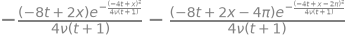

In [21]:
deriv_phi = phi.diff(x)
deriv_phi

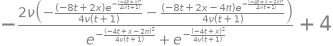

In [22]:
u = -2 * nu * deriv_phi / phi + 4
u

### Lambdify

The `Lambdify` function will convert `SymPy` expressions into usable functions with variables that one can define like python functions.

In [23]:
from sympy.utilities.lambdify import lambdify

u_function = lambdify((x, nu, t), u)

Now we can finish setting up the initial condition of the problem with our new toolset.

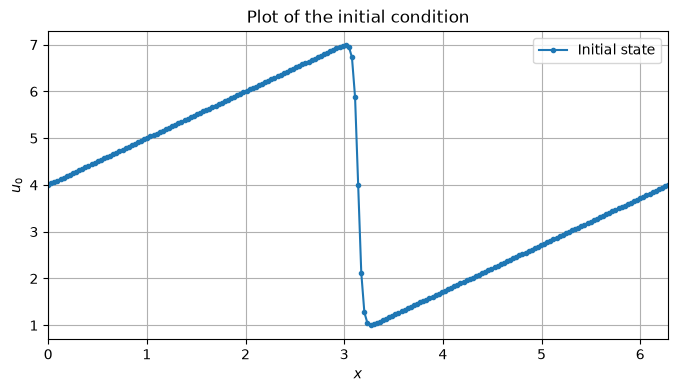

In [24]:
nx, x_range = 201, [0, 2 * np.pi]
nu = 0.07

x_array = np.linspace(x_range[0], x_range[1], nx)
u_0 = np.asarray([u_function(x, nu, 0) for x in x_array]) # Convert u_function to a numpy array u using np.asarray

plt.figure(figsize=(8, 4))

plt.plot(x_array, u_0, ".-", label='Initial state')

plt.xlabel(r'$x$')
plt.ylabel(r'$u_0$')
plt.title('Plot of the initial condition')

plt.xlim(x_range)

plt.grid(True)
plt.legend()
plt.show()


With the periodic boundary conditions, when a point gets to the right-hand side of the frame, it wraps around back to the left of the frame. We find that $u^n_{i_{max}} = u^n_0$ and $i_{max} + 1 = 1$

In [25]:
def periodic_burgers(u_0: np.ndarray, domain: list[float], nx: int, nt: int, nu: float = 0.3) -> tuple[np.ndarray, float]:
    dx = abs(domain[1] - domain[0]) / (nx - 1)
    dt =  dx * nu

    u = np.zeros([nt+1, nx])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        for i in range(1, nx-1):
            u[n+1, i] = (u[n, i] - u[n, i] * dt / dx * (u[n, i] - u[n, i-1]) + nu * dt / dx**2 * (u[n, i+1] - 2 * u[n, i] + u[n, i-1]))

        # Implement periodic boundary conditions where the first and last points are connected to each other
        u[n+1, -1] = (u[n, -1] - u[n, -1] * dt / dx * (u[n, -1] - u[n, -2]) + nu * dt / dx**2 * (u[n, 1] - 2 * u[n, -1] + u[n, -2]))
        u[n+1, 0] = u[n+1, -1]

    return u, dt

Let's observe how this evolves from its initial state.

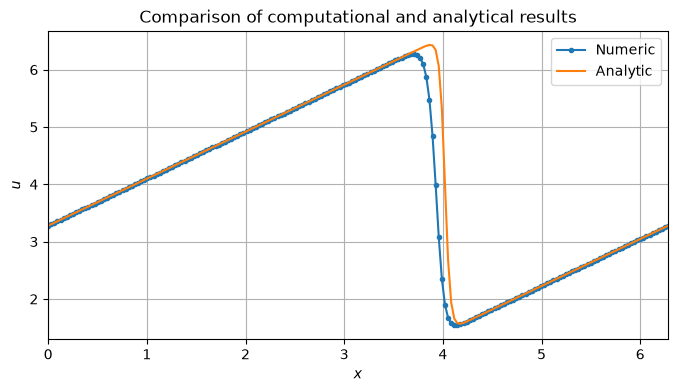

In [26]:
nx, x_range = 201, [0, 2 * np.pi]
dt = 2 * np.pi / (nx - 1)
nu = 0.07

x_array = np.linspace(x_range[0], x_range[1], nx)
u_0 = np.asarray([u_function(x, nu, 0) for x in x_array])
nt = 100

u_numeric, dt = periodic_burgers(u_0=u_0, domain=x_range, nx=nx, nt=nt, nu=nu)
u_analy = np.asarray([u_function(x, nu, nt * dt) for x in x_array])

plt.figure(figsize=(8, 4))

plt.plot(x_array, u_numeric[-1], ".-", label='Numeric')
plt.plot(x_array, u_analy, label='Analytic')

plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.title('Comparison of computational and analytical results')

plt.xlim([0, 2*np.pi])

plt.grid(True)
plt.legend()
plt.show()

Increased grid resolution gets these two solutions even closer to one another.

## 2<sup>D</sup> Linear Convection

To advance to higher dimensions we make use of the fact that cartesian coordinates and orthogonal. Noting this, it follows that a partial derivative w.r.t $x$ is the variation in $x$ at constant $y$ and therefore these two coordinates have exclusive operators in equations of motion.

In uniform 2<sup>D</sup> space, a grid is defined by the points with coordinates $x_i = x_0 + i \Delta x$ and $y_j = y_0 + j \Delta y$. We let $u \equiv u(x, y)$ and apply difference formulaes on either variables acting seperately on the indices $i, j$. Using the 2<sup>D</sup> Taylor expansion we may obtain the first derivates around u_{i, j}. For examples, in $x$,

$$\frac{\partial u}{\partial x} \Bigr| _{i, j} = \frac{u_{i+1, j} - u_{i, j}}{\Delta x} + \mathcal{O}(\Delta x)$$

2<sup>D</sup> Linear Convection is governed by

$$\frac{\partial u}{\partial t} + c \Bigr( \frac{\partial u}{\partial x} + \frac{\partial u}{\partial y} \Bigr) = 0$$

with a discretisation:

$$\frac{u^{n+1}_{i, j} - u^n_{i, j}}{\Delta t} + c \Bigr( \frac{u^{n}_{i, j} - u^n_{i-1, j}}{\Delta x} + \frac{u^{n}_{i, j} - u^n_{i, j-1}}{\Delta y} \Bigr) = 0$$

that rearranges to

$$u^{n+1}_{i, j} =  u^n_{i, j} - c \Delta t \Bigr( \frac{u^{n}_{i, j} - u^n_{i-1, j}}{\Delta x} + \frac{u^{n}_{i, j} - u^n_{i, j-1}}{\Delta y} \Bigr)$$

We will use our traditional top hat initial conditions:

$$ u_0 = \begin{cases} 1 & 0.1 < x, y < 0.3 \\ 0 & \text{elsewhere} \end{cases}$$

In [27]:
def top_hat_2d(nx: int, ny: int, x_range: list[float] = [0.0, 1.0], y_range: list[float] = [0.0, 1.0], centre: tuple[float, float] = (0.5, 0.5),
               width: tuple[float, float] = (0.2, 0.2), max_value: float = 1.0, min_value: float = 0.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = np.linspace(x_range[0], x_range[1], nx)
    y = np.linspace(y_range[0], y_range[1], ny)

    X, Y = np.meshgrid(x, y, indexing='ij')

    mask = ((np.abs(X - centre[0]) <= width[0] / 2) & (np.abs(Y - centre[1]) <= width[1] / 2))

    array = np.full((nx, ny), min_value, dtype=float)
    array[mask] = max_value

    return array, x, y

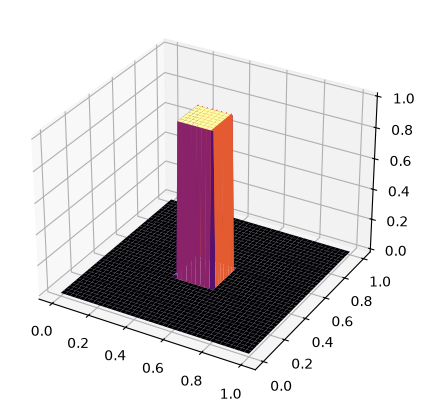

In [28]:
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
dx = (x_range[1] - x_range[0]) / (nx - 1)
dy = (y_range[1] - y_range[0]) / (ny - 1)

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
X, Y = np.meshgrid(x,y)

fig = plt.figure(figsize = (10, 5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, u_0, cmap="inferno")

### Optimisations

Let's try to use `NumPy` abit more effectively to optimise computational speed. `NumPy` arrays and operations can replace for-loops, allowing for the predefinition of allocated memory, thereby increasing execution speed. The `%%timeit` iPython "magic" function will allow us to evaluate cell speed. This behaviour falls under the umbrella of numpy vectorisation. As a simple example consider $u^{n+1}_i = u^n_i - u^n_{i-1}$ that returns the difference between sucessive terms in an array. This can either be solved by nested for-loops that iterate over all elements of a vector $u$, or an array operation tha slices the array and calculates each operation with one command:

In [29]:
u = np.array((0,1,2,4,6,9))
u_diff = np.zeros(len(u)-1) # one shorter than u to store the differences between consecutive elements

for i in range(1, len(u)):
    u_diff[i-1] = u[i] - u[i-1] 

print(u_diff)

# OR

print(u[1:]) # elements from index 1 to end
print(u[0:-1]) # elements from index 0 to second last
u_diff = u[1:] - u[0:-1] # difference between consecutive elements
print(u_diff)


[1. 1. 2. 2. 3.]
[1 2 4 6 9]
[0 1 2 4 6]
[1 1 2 2 3]


This will become particular significant as we advance to higher dimensions so let's explore a simple optimisations in 2<sup>D</sup> with the same top hat initial condition extended to 2<sup>D</sup>. Let's see how it improves 2<sup>D</sup> linear convection.

### For-loop 2<sup>D</sup> Linear Convection

In [30]:
def simple_linear_convection_2d(u_0: np.ndarray, nx: int, ny: int, nt: int, x_range: list[float], y_range: list[float], c: float = 1.0, cfl: float = 0.2) -> np.ndarray:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    dy = (y_range[1] - y_range[0]) / (ny - 1)
    dt = cfl * c / (1/dx + 1/dy)

    u = np.zeros([nt+1, nx, ny])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy() # keep boundary values consistent
        for i in range(1, nx):
            for j in range(1, ny):
                u[n+1, i, j] = u[n, i, j] - c * dt * ((u[n, i, j] - u[n, i-1, j]) / dx + (u[n, i, j] - u[n, i, j-1]) / dy)
    return u

In [31]:
%%timeit
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
nt = 100

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
simple_linear_convection_2d(u_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range)

302 ms ± 8.41 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Vectorised 2<sup>D</sup> Linear Convection

In [32]:
def vector_linear_convection_2d(u_0: np.ndarray, nx: int, ny: int, nt: int, x_range: list[float], y_range: list[float], c: float = 1.0, cfl: float = 0.2) -> np.ndarray:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    dy = (y_range[1] - y_range[0]) / (ny - 1)
    dt = cfl * c / (1/dx + 1/dy)

    u = np.zeros([nt+1, nx, ny])
    u[0] = u_0.copy()
    
    for n in range(nt):
        u[n+1] = u[n].copy()
        u[n+1, 1:, 1:] = u[n, 1:, 1:] - c * dt * ((u[n, 1:, 1:] - u[n, 0:-1, 1:]) / dx + (u[n, 1:, 1:] - u[n, 1:, 0:-1]) / dy)

    return u

In [33]:
%%timeit
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
nt = 100

u_0, x, y = top_hat_2d(nx, ny)
vector_linear_convection_2d(u_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range)

4.08 ms ± 33.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


This second version is significantly faster thanks to the use of numpy vectorisation, replacing the double loop with a single vectorisation. They key is understanding each slice in its context:

| Slice | Meaning |
| ----- | ------- |
| u[n, 1:, 1:] | Current point from i, j = 1 to their ends |
| u[n, 0:-1, 1:] | Left neighbor, i = 0 to second last, i.e. shifting x-index back by 1 |
| u[n, 1:, 0:-1] | Bottom neighbor, j = 0 to second last, i.e. shifting y-index back by 1 |

This method can be many orders of magnitude faster than the basic method, especially for large grids. We'll plot the two results side-by-side to verify they are the same.

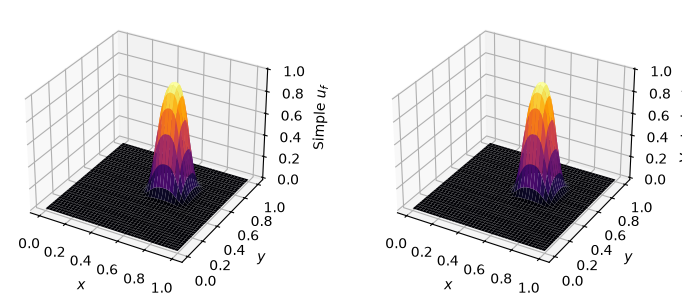

In [69]:
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
nt = 100

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
u_simple = simple_linear_convection_2d(u_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range)
u_adv = vector_linear_convection_2d(u_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range)

X, Y = np.meshgrid(x,y)

fig = plt.figure(figsize = (8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, u_simple[-1], cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"Simple $u_f$")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, u_adv[-1], cmap="inferno")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"Vectorised $u_f$")

plt.tight_layout()
plt.show()

# 2<sup>D</sup> Nonlinear Convection

Non linear convection is represented by two coupled PDEs

$$\frac{\partial u}{\partial t} + u \Bigr( \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} \Bigr) = 0$$

$$\frac{\partial v}{\partial t} + u \Bigr( \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} \Bigr) = 0$$

with a discretisation:

$$\frac{u^{n+1}_{i, j} - u^n_{i, j}}{\Delta t} + u \Bigr( \frac{u^{n}_{i, j} - u^n_{i-1, j}}{\Delta x} + v \frac{u^{n}_{i, j} - u^n_{i, j-1}}{\Delta y} \Bigr) = 0$$

$$\frac{v^{n+1}_{i, j} - v^n_{i, j}}{\Delta t} + u \Bigr( \frac{v^{n}_{i, j} - v^n_{i-1, j}}{\Delta x} + v \frac{v^{n}_{i, j} - v^n_{i, j-1}}{\Delta y} \Bigr) = 0$$

that rearranges to

$$u^{n+1}_{i, j} =  u^n_{i, j} - u^n_{i, j} \frac{\Delta t}{\Delta x} (u^{n}_{i, j} - u^n_{i-1, j}) + v^n_{i, j} \frac{\Delta t}{\Delta y} (u^{n}_{i, j} - u^n_{i, j-1})$$

$$v^{n+1}_{i, j} =  v^n_{i, j} - u^n_{i, j} \frac{\Delta t}{\Delta x} (v^{n}_{i, j} - v^n_{i-1, j}) + v^n_{i, j} \frac{\Delta t}{\Delta y} (v^{n}_{i, j} - v^n_{i, j-1})$$

In [35]:
def nonlinear_convection_2d(u_0: np.ndarray, v_0: np.ndarray, nx: int, ny: int, nt: int, 
                            x_range: list[float], y_range: list[float], dt: float) -> tuple[np.ndarray, np.ndarray]:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    dy = (y_range[1] - y_range[0]) / (ny - 1)

    u = np.zeros([nt+1, nx, ny])
    u[0] = u_0.copy()
    v = np.zeros([nt+1, nx, ny])
    v[0] = v_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        v[n+1] = v[n].copy()

        u[n+1, 1:, 1:] = (u[n, 1:, 1:] - (u[n, 1:,1:] * dt / dx * (u[n, 1:, 1:] - u[n, 0:-1, 1:])) -
                        v[n, 1:, 1:] * dt / dy * (u[n, 1:, 1:] - u[n, 1:, 0:-1]))
        v[n+1, 1:, 1:] = (v[n, 1:, 1:] - (u[n, 1:, 1:] * dt / dx * (v[n, 1:, 1:] - v[n, 0:-1, 1:])) -
                        v[n, 1:, 1:] * dt / dy * (v[n, 1:, 1:] - v[n, 1:, 0:-1]))

    return u, v

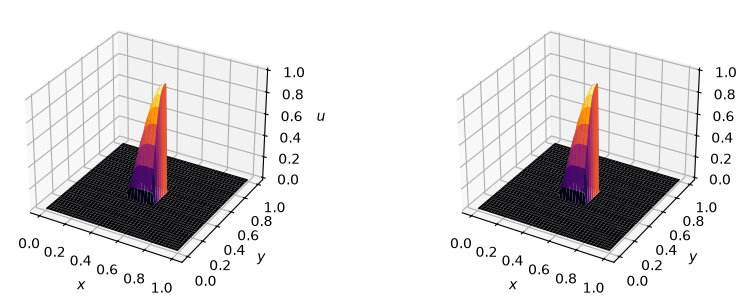

In [ ]:
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
nt, dt = 50, 0.002

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
u, v = nonlinear_convection_2d(u_0=u_0, v_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range, dt=dt)

X, Y = np.meshgrid(x,y)

fig = plt.figure(figsize = (8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, u[-1], cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"$u$")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, v[-1], cmap="inferno")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"$v$")

plt.tight_layout()
plt.show()

## 2<sup>D</sup> Diffusion

The explicit solver for the 2<sup>D</sup> diffusion eq<sup>n</sup> is given by

$$ \frac{\partial u}{\partial t} = \nu \Bigr( \frac{\partial ^2 u}{\partial x^2} + \frac{\partial ^2 u}{\partial y^2} \Bigr)$$

As before this is discretised to

$$\frac{u^{n+1}_{i, j} - u^{n}_{i, j}}{\Delta t} = \nu \Bigr( \frac{u^{n}_{i+1, j} - 2 u^{n}_{i, j} + u^{n}_{i-1, j}}{\Delta x^2} + \frac{u^{n}_{i, j+1} - 2 u^{n}_{i, j} + u^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

which rearranges to

$$u^{n+1}_{i, j} = u^{n}_{i, j} + \nu \Delta t \Bigr( \frac{u^{n}_{i+1, j} - 2 u^{n}_{i, j} + u^{n}_{i-1, j}}{\Delta x^2} + \frac{u^{n}_{i, j+1} - 2 u^{n}_{i, j} + u^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

In [56]:
def diffusion_2d(u_0: np.ndarray,  nx: int, ny: int, nt: int, x_range: list[float], y_range: list[float], 
                 nu: float = 0.1, sigma: float = 0.2) -> np.ndarray:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    dy = (y_range[1] - y_range[0]) / (ny - 1)
    dt = sigma * dx * dy / nu

    u = np.zeros([nt+1, nx, ny])
    u[0] = u_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()

        u[n+1, 1:-1, 1:-1] = u[n, 1:-1, 1:-1] + nu * dt * ((u[n, 2:, 1:-1] - 2 * u[n, 1:-1, 1:-1] + u[n, 0:-2, 1:-1]) / dx**2 + 
                                                           (u[n, 1:-1, 2:] - 2 * u[n, 1:-1, 1:-1] + u[n, 1:-1, 0:-2]) / dy**2)

    return u

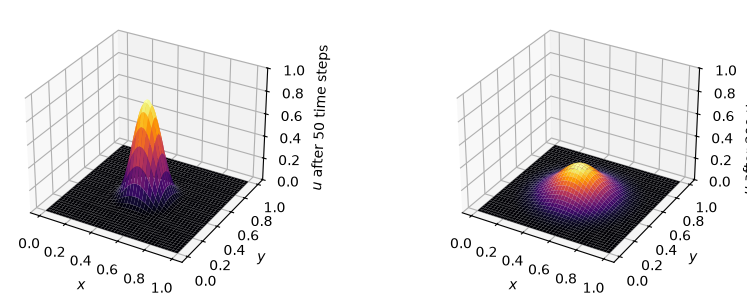

In [ ]:
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
X, Y = np.meshgrid(x,y)

fig = plt.figure(figsize = (8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, diffusion_2d(u_0=u_0, nx=nx, ny=ny, nt=50, x_range=x_range, y_range=y_range)[-1], cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"$u$ after 50 time steps")
ax1.set_zlim(0, 1)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, diffusion_2d(u_0=u_0, nx=nx, ny=ny, nt=300, x_range=x_range, y_range=y_range)[-1], cmap="inferno")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"$u$ after 300 time steps")
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.show()

The discretisation of the 2<sup>D</sup> is not step dependent, so long at the choice of step is local in time i.e. in the ideal limit, the approximation about $n$ is very close to $n+1$. Our explicit solver above uses the previous state, $n$, to predict the next state $n+1$ a small time step, $\Delta t$, later. Conversely, implicit solvers mix information from the current and future step to calculate its evolution. The benefit of this is stability, allowing for larger time steps and thereby longer computational periods.

## Burgers' Eq<sup>n</sup> in 2<sup>D</sup>

Burgers' eq<sup>n</sup> in 2<sup>D</sup> turn out to be a coupled set of PDEs, owing to their nonlinearity:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = \nu \Bigr( \frac{\partial ^2 u}{\partial x^2} + \frac{\partial ^2 u}{\partial y^2} \Bigr)$$

$$\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = \nu \Bigr( \frac{\partial ^2 v}{\partial x^2} + \frac{\partial ^2 v}{\partial y^2} \Bigr)$$

where $u$ and $v$ are perpendicular components (i.e. horzizontal and vertical) of the fluid velocity. As usual we discretise in the explicit case:

$$\frac{u^{n+1}_{i, j} - u^{n}_{i, j}}{\Delta t} + u^n_{i,j} \frac{u^{n}_{i, j} - u^{n}_{i-1, j}}{\Delta x} + v^n_{i,j} \frac{u^{n}_{i, j} - u^{n}_{i, j-1}}{\Delta y} = \nu \Bigr( \frac{u^{n}_{i+1, j} - 2 u^{n}_{i, j} + u^{n}_{i-1, j}}{\Delta x^2} + \frac{u^{n}_{i, j+1} - 2 u^{n}_{i, j} + u^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

$$\frac{v^{n+1}_{i, j} - v^{n}_{i, j}}{\Delta t} + u^n_{i,j} \frac{v^{n}_{i, j} - v^{n}_{i-1, j}}{\Delta x} + v^n_{i,j} \frac{v^{n}_{i, j} - v^{n}_{i, j-1}}{\Delta y} = \nu \Bigr( \frac{v^{n}_{i+1, j} - 2 v^{n}_{i, j} + v^{n}_{i-1, j}}{\Delta x^2} + \frac{v^{n}_{i, j+1} - 2 v^{n}_{i, j} + v^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

which rearrange to

$$u^{n+1}_{i, j} = u^{n}_{i, j} - u^n_{i,j} \frac{\Delta t}{\Delta x} (u^{n}_{i, j} - u^{n}_{i-1, j}) - v^n_{i,j} \frac{\Delta t}{\Delta y} (u^{n}_{i, j} - u^{n}_{i, j-1}) + \nu \Delta t \Bigr( \frac{u^{n}_{i+1, j} - 2 u^{n}_{i, j} + u^{n}_{i-1, j}}{\Delta x^2} + \frac{u^{n}_{i, j+1} - 2 u^{n}_{i, j} + u^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

$$v^{n+1}_{i, j} = v^{n}_{i, j} - u^n_{i,j} \frac{\Delta t}{\Delta x} (v^{n}_{i, j} - v^{n}_{i-1, j}) - v^n_{i,j} \frac{\Delta t}{\Delta y} (v^{n}_{i, j} - v^{n}_{i, j-1}) + \nu \Delta t \Bigr( \frac{v^{n}_{i+1, j} - 2 v^{n}_{i, j} + v^{n}_{i-1, j}}{\Delta x^2} + \frac{v^{n}_{i, j+1} - 2 v^{n}_{i, j} + v^{n}_{i, j-1}}{\Delta y^2} \Bigr)$$

In [58]:
def burger_2d(u_0: np.ndarray, v_0: np.ndarray,  nx: int, ny: int, nt: int, x_range: list[float], y_range: list[float], 
              nu: float = 0.1, sigma: float = 0.2) -> tuple[np.ndarray, np.ndarray]:
    dx = (x_range[1] - x_range[0]) / (nx - 1)
    dy = (y_range[1] - y_range[0]) / (ny - 1)

    # Explicit stability bound from diffusion part (2D FTCS).
    dt_diff = sigma / (nu * (1 / dx**2 + 1 / dy**2))

    u = np.zeros([nt+1, nx, ny])
    u[0] = u_0.copy()
    v = np.zeros([nt+1, nx, ny])
    v[0] = v_0.copy()

    for n in range(nt):
        u[n+1] = u[n].copy()
        v[n+1] = v[n].copy()

        # Add an advection CFL cap to avoid blow-up when velocities grow.
        umax = np.max(np.abs(u[n+1]))
        vmax = np.max(np.abs(v[n+1]))
        dt_adv_x = np.inf if umax == 0 else sigma * dx / umax
        dt_adv_y = np.inf if vmax == 0 else sigma * dy / vmax
        dt = min(dt_diff, dt_adv_x, dt_adv_y)

        u[n + 1, 1:-1, 1:-1] = (u[n, 1:-1, 1:-1] - 
                                u[n, 1:-1, 1:-1] * dt / dx * (u[n, 1:-1, 1:-1] - u[n, :-2, 1:-1]) - 
                                v[n, 1:-1, 1:-1] * dt / dy * (u[n, 1:-1, 1:-1] - u[n, 1:-1, :-2]) + nu * dt *
                                ((u[n, 2:, 1:-1] - 2 * u[n, 1:-1, 1:-1] + u[n, :-2, 1:-1]) / dx**2 + 
                                 (u[n, 1:-1, 2:] - 2 * u[n, 1:-1, 1:-1] + u[n, 1:-1, :-2]) / dy**2))
        v[n + 1, 1:-1, 1:-1] = (v[n, 1:-1, 1:-1] - 
                                u[n, 1:-1, 1:-1] * dt / dx * (v[n, 1:-1, 1:-1] - v[n, :-2, 1:-1]) - 
                                v[n, 1:-1, 1:-1] * dt / dy * (v[n, 1:-1, 1:-1] - v[n, 1:-1, :-2]) + nu * dt * 
                                ((v[n, 2:, 1:-1] - 2 * v[n, 1:-1, 1:-1] + v[n, :-2, 1:-1]) / dx**2 + 
                                 (v[n, 1:-1, 2:] - 2 * v[n, 1:-1, 1:-1] + v[n, 1:-1, :-2]) / dy**2))
        
    return u, v

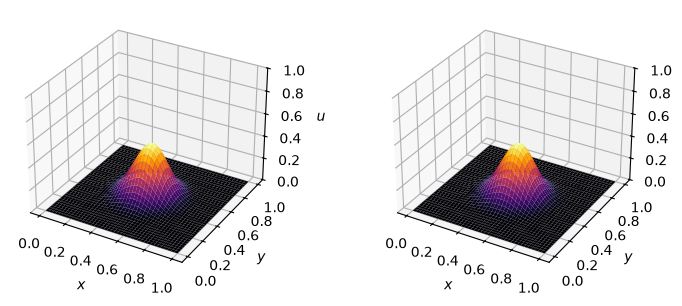

In [66]:
nx, x_range = 81, [0.0, 1.0]
ny, y_range = 81, [0.0, 1.0]
nt = 300

u_0, x, y = top_hat_2d(nx, ny, x_range=x_range, y_range=y_range)
u, v = burger_2d(u_0=u_0, v_0=u_0, nx=nx, ny=ny, nt=nt, x_range=x_range, y_range=y_range)

X, Y = np.meshgrid(x,y)

fig = plt.figure(figsize = (8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, u[-1], cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"$u$")
ax1.set_zlim(0, 1)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, v[-1], cmap="inferno")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"$v$")
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.show()

## Laplace's Eq<sup>n</sup>

Laplace's Eq<sup>n</sup> is a special case of Poisson's Eq<sup>n</sup> that we cover later,

$$\nabla ^2 f \equiv \frac{\partial ^2 f}{\partial x^2} + \frac{\partial ^2 f}{\partial y^2} \Bigr( + \frac{\partial ^2 f}{\partial z^2} \Bigr) = 0$$

We already have the form of the discretised 2nd-order derivative so this discretises fairly plainly in 2-dimensions.

$$\frac{f^{n}_{i+1, j} - 2 f^{n}_{i, j} + f^{n}_{i-1, j}}{\Delta x^2} + \frac{f^{n}_{i, j+1} - 2 f^{n}_{i, j} + f^{n}_{i, j-1}}{\Delta y^2} = 0$$

Laplaces equations are very useful in finding the steady incompressible, irrotational flow of fluids and applies to most potential fields with flow, extending to heat and electromagnetism. Instead of calculating the next state, $n+1$, i.e. estimating a system's time evolution, the eq<sup>n</sup> finds the equilibrium state according to a systems boundary conditions. A system can only truly reach equilibrium as $n \rightarrow \infty$, but the approximate steady-state can be found discretely when the variations between states become very small. We can rearrange to solve for the centered state $n, i, j$,

$$f^{n}_{i, j} = \frac{\Delta y^2 (f^n_{i+1, j} - f^n_{i-1, j}) + \Delta x^2 (f^n_{i, j+1} - f^n_{i, j-1})}{2(\Delta x^2 + \Delta y^2)}$$

The use of the 2nd-order central-difference schemes in both directions is a widely used discretisation of the Laplacian, sometimes known as the five-point difference operator.

We set up the investigation with the initial condition that $p=0$ everywhere, then applying the following boundary conditions:

$$f = \begin{cases} 0 & x = 0 \\ y & x = 2 \end{cases}$$

$$\frac{\partial f}{\partial y} = 0 \text{ for } \{y = 0, 1\}$$

to meet this second condition we make use of the fact that

$$ \frac{\partial f}{\partial y} \approx \frac{f^{n}_{i, j} - f^{n}_{i, j-1}}{\Delta y} = 0$$

This is only true if the numerator is $0$ so it follows that

$$f^{n}_{i, j} = f^{n}_{i, j-1}$$

This can be readily vectorised and implemented into our iterative function. It is also noted that the conditions above have an analytical solution that we may reference:

$$f(x, y) = \frac{x}{4} - 4 \sum^\infty_{n = 1, \text{odd}} \frac{\sinh(n \pi x) \cos(n \pi y)}{(n \pi)^2 \sinh (2 n \pi)}$$

In [122]:
def boundary_conditions(f: np.ndarray, y: np.ndarray) -> np.ndarray:
    f[:, 0] = 0         # f(bottom)      = 0
    f[:, -1] = y        # f(top)         = y
    f[0, :] = f[1, :]   # df/dy (bottom) = 0
    f[-1, :] = f[-2, :] # df/dy (top)    = 0
    return f

In [123]:
def initial_laplacian_state(nx: int, ny: int, x_range: list[float], y_range: list[float]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    f = np.zeros([nx, ny])

    x = np.linspace(x_range[0], x_range[1], nx)
    y = np.linspace(y_range[0], y_range[1], ny)

    f = boundary_conditions(f, y)

    return f, x, y

In [ ]:
def laplace_2d(f: np.ndarray, nx: int, ny: int, x_range: list[float], y_range: list[float], y: np.ndarray,
               l1norm_target: float = 1e-4, max_iter: int = 10000) -> np.ndarray:
    dx = abs(x_range[1] - x_range[0]) / (nx - 1)
    dy = abs(y_range[1] - y_range[0]) / (ny - 1)

    f = f.copy() # work on a copy of the input array to avoid modifying it in place
    l1norm = 1.0
    iters = 0 # counter guard to prevent infinite loops in case of non-convergence

    while l1norm > l1norm_target and iters < max_iter:
        f_prior = f.copy()
        f[1:-1, 1:-1] = (dy**2 * (f_prior[2:, 1:-1] + f_prior[:-2, 1:-1]) + 
                         dx**2 * (f_prior[1:-1, 2:] + f_prior[1:-1, :-2])) / (2 * (dx**2 + dy**2))
        f = boundary_conditions(f, y)

        denominator = np.sum(np.abs(f_prior))
        l1norm = np.sum(np.abs(f - f_prior)) if denominator == 0 else np.sum(np.abs(f - f_prior)) / denominator
        iters += 1

    return f

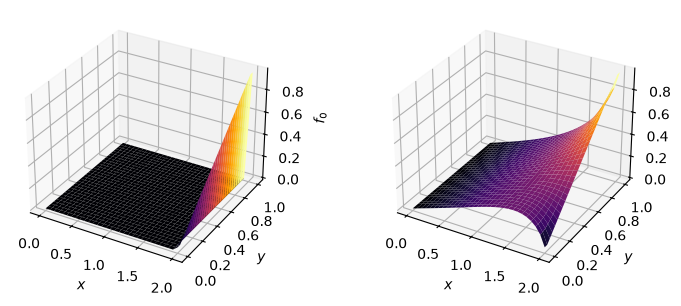

In [134]:
nx, x_range = 31, [0.0, 2.0]
ny, y_range = 31, [0.0, 1.0]

f_0, x, y = initial_laplacian_state(nx=nx, ny=ny, x_range=x_range, y_range=y_range)
f = laplace_2d(f=f_0, nx=nx, ny=ny, x_range=x_range, y_range=y_range, y=y)

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, f_0, cmap="inferno")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"$f_0$")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, f, cmap="inferno")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"$f$")

plt.tight_layout()
plt.show()

### Erata

Split 4 and $\phi$ in Step 5 I & B C

nt + 1 unjustifed in Step 6

Explicit 2d diffusion solvers listed twice in step 9

dt = sigma * dx not dimensionally sound in step 10

l1norm = (np.sum(np.abs(p[:])-np.abs(pn[:])) / np.sum(np.abs(pn[:]))) should be absolute of differences not difference of absolutes in step 11

mismatched p[:, 0] = 0  # p = 0 @ x = 0
p[:, -1] = y  # p = y @ x = 2
p[0, :] = p[1, :]  # dp/dy = 0 @ y = 0
p[-1, :] = p[-2, :]  # dp/dy = 0 @ y = 1 in step 11.